# Othello AI — MCTS Bots of Varying Difficulty

This notebook contains a complete Othello (Reversi) engine and a suite of AI bots
ranging from **Easy** (greedy) to **Hard** (MCTS + learned value function).

**Contents**
1. Game Engine (`Othello`) — bitboard implementation for fast move generation
2. Easy Bot — Greedy
3. Medium Bot — Heuristic
4. Hard Bots — MCTS variants (baseline, heuristic rollout, TDL value function, combined, optimised)
5. TDL Training
6. Simulation & Evaluation
7. Play a Game (Human vs Bot)
8. Presentation Visuals


In [1]:
import platform
print(platform.machine())   # should print arm64

arm64


## 1. Game Engine

Rewritten using **64-bit bitboards** instead of a list-of-lists board.
The entire board is stored as two integers (`black_bb`, `white_bb`) — one bit per square.
Move generation, disc flipping, and game-over detection all become bitwise operations
with no per-cell Python loops.

**Measured speedups vs the original list-based engine:**

| Operation | Before | After | Speedup |
|-----------|--------|-------|---------|
| `get_legal_moves` | 5.56 µs | 1.04 µs | **5.4×** |
| `clone` | 2.73 µs | 0.18 µs | **15×** |
| Full MCTS (100 sims) | 1.59 s | 0.21 s | **7.5×** |

The public API (`get_legal_moves`, `apply_move`, `clone`, `board`, etc.) is identical
to the original, so every bot works without modification.


In [2]:
"""
Othello engine using 64-bit bitboards.

Each board state is two integers:
  black_bb  — one bit set per BLACK disc  (bit index = row*8 + col)
  white_bb  — one bit set per WHITE disc

All move generation, flipping, and game-over detection are pure
bitwise operations with no per-cell Python loops.
"""

EMPTY = 0
BLACK = 1
WHITE = -1

# ── bit-twiddling helpers ──────────────────────────────────────────────────────
_FULL  = (1 << 64) - 1
_NOT_A = 0xFEFEFEFEFEFEFEFE  # mask out col 0 (prevents wrap going left)
_NOT_H = 0x7F7F7F7F7F7F7F7F  # mask out col 7 (prevents wrap going right)

# (shift_amount, wrap_mask) for each of the 8 directions
# positive shift = rightward in bit space = East/South on board
_DIRS = [
    ( 1, _NOT_H),  # E
    (-1, _NOT_A),  # W
    ( 8, _FULL),   # S
    (-8, _FULL),   # N
    ( 9, _NOT_H),  # SE
    (-9, _NOT_A),  # NW
    ( 7, _NOT_A),  # SW
    (-7, _NOT_H),  # NE
]

def _shift(bb: int, d: int, mask: int) -> int:
    if d > 0:
        return (bb >> d) & mask
    return (bb << (-d)) & mask & _FULL

def _legal_moves_bb(my_bb: int, opp_bb: int) -> int:
    """Return a bitboard of all legal moves for the player owning my_bb."""
    empty = ~(my_bb | opp_bb) & _FULL
    moves = 0
    for d, mask in _DIRS:
        candidates = _shift(my_bb, d, mask) & opp_bb
        for _ in range(5):  # slide up to 6 squares in one direction
            candidates |= _shift(candidates, d, mask) & opp_bb
        moves |= _shift(candidates, d, mask) & empty
    return moves

def _flip_discs_bb(move_bit: int, my_bb: int, opp_bb: int):
    """Return (new_my_bb, new_opp_bb) after placing move_bit."""
    flipped = 0
    for d, mask in _DIRS:
        candidates = _shift(move_bit, d, mask) & opp_bb
        for _ in range(5):
            candidates |= _shift(candidates, d, mask) & opp_bb
        if _shift(candidates, d, mask) & my_bb:
            flipped |= candidates
    return my_bb | move_bit | flipped, opp_bb & ~flipped

def _bb_to_moves(bb: int):
    """Convert a bitboard to a list of (row, col) tuples."""
    moves = []
    while bb:
        lsb = bb & (-bb)
        idx = lsb.bit_length() - 1
        moves.append((idx >> 3, idx & 7))
        bb &= bb - 1
    return moves


class Othello:
    """64-bit bitboard Othello engine. Drop-in replacement for the original."""

    __slots__ = ('black_bb', 'white_bb', 'current_player')

    def __init__(self):
        self.black_bb = (1 << (3*8+4)) | (1 << (4*8+3))
        self.white_bb = (1 << (3*8+3)) | (1 << (4*8+4))
        self.current_player = BLACK

    @property
    def board(self):
        """8×8 list view — used by heuristic eval; fast path skips this."""
        b = [[EMPTY]*8 for _ in range(8)]
        bb = self.black_bb
        while bb:
            lsb = bb & (-bb); idx = lsb.bit_length() - 1
            b[idx>>3][idx&7] = BLACK; bb &= bb-1
        wb = self.white_bb
        while wb:
            lsb = wb & (-wb); idx = lsb.bit_length() - 1
            b[idx>>3][idx&7] = WHITE; wb &= wb-1
        return b

    def clone(self):
        g = Othello.__new__(Othello)
        g.black_bb = self.black_bb
        g.white_bb = self.white_bb
        g.current_player = self.current_player
        return g

    def in_bounds(self, r, c):
        return 0 <= r < 8 and 0 <= c < 8

    def _my_opp(self, player):
        return (self.black_bb, self.white_bb) if player == BLACK \
               else (self.white_bb, self.black_bb)

    def get_legal_moves(self, player=None):
        if player is None: player = self.current_player
        return _bb_to_moves(_legal_moves_bb(*self._my_opp(player)))

    def _is_valid_move(self, r, c, player):
        return bool(_legal_moves_bb(*self._my_opp(player)) & (1 << (r*8+c)))

    def apply_move(self, move, player=None):
        if player is None: player = self.current_player
        if move is None:
            self.current_player = -player; return
        r, c = move
        my_bb, opp_bb = self._my_opp(player)
        new_my, new_opp = _flip_discs_bb(1 << (r*8+c), my_bb, opp_bb)
        if player == BLACK:
            self.black_bb, self.white_bb = new_my, new_opp
        else:
            self.white_bb, self.black_bb = new_my, new_opp
        self.current_player = -player

    def has_any_moves(self, player):
        return bool(_legal_moves_bb(*self._my_opp(player)))

    def is_game_over(self):
        return not self.has_any_moves(BLACK) and not self.has_any_moves(WHITE)

    def get_winner(self):
        bc = bin(self.black_bb).count('1')
        wc = bin(self.white_bb).count('1')
        return BLACK if bc > wc else (WHITE if wc > bc else 0)

    def get_score(self):
        return {'black': bin(self.black_bb).count('1'),
                'white': bin(self.white_bb).count('1')}

    def print_board(self):
        symbols = {BLACK: 'B', WHITE: 'W', EMPTY: '.'}
        b = self.board
        print('  0 1 2 3 4 5 6 7')
        for i in range(8):
            print(f'{i} ' + ' '.join(symbols[b[i][j]] for j in range(8)))


print('Bitboard Othello engine loaded.')
print(f'Starting moves: {sorted(Othello().get_legal_moves())}')


Bitboard Othello engine loaded.
Starting moves: [(2, 3), (3, 2), (4, 5), (5, 4)]


## 2. Easy Bot — Greedy

Picks whichever legal move immediately captures the most discs. No lookahead whatsoever.


In [3]:
class GreedyBot:
    """Easy difficulty. Maximises immediate disc captures with no lookahead."""

    def choose_move(self, game, player=None):
        if player is None:
            player = game.current_player
        moves = game.get_legal_moves(player)
        if not moves:
            return None

        best_move, best_score = None, float("-inf")
        for move in moves:
            test_game = game.clone()
            test_game.apply_move(move, player)
            score = sum(cell == player for row in test_game.board for cell in row)
            if score > best_score:
                best_score = score
                best_move = move
        return best_move

print("GreedyBot (Easy) loaded.")


GreedyBot (Easy) loaded.


## 3. Medium Bot — Heuristic

Uses a position-weight table (corners are very valuable, X-squares next to corners
are dangerous) plus a mobility bonus. Still no tree search — purely one-ply evaluation.


In [4]:
POSITION_WEIGHTS = [
    [100, -20,  10,   5,   5,  10, -20, 100],
    [-20, -50,  -2,  -2,  -2,  -2, -50, -20],
    [ 10,  -2,  -1,  -1,  -1,  -1,  -2,  10],
    [  5,  -2,  -1,  -1,  -1,  -1,  -2,   5],
    [  5,  -2,  -1,  -1,  -1,  -1,  -2,   5],
    [ 10,  -2,  -1,  -1,  -1,  -1,  -2,  10],
    [-20, -50,  -2,  -2,  -2,  -2, -50, -20],
    [100, -20,  10,   5,   5,  10, -20, 100],
]


class HeuristicBot:
    """Medium difficulty. One-ply heuristic: position weights + mobility."""

    def choose_move(self, game, player=None):
        if player is None:
            player = game.current_player
        moves = game.get_legal_moves(player)
        if not moves:
            return None

        best_move, best_score = None, float("-inf")
        for move in moves:
            new_board = game.clone()
            new_board.apply_move(move, player)
            score = self._evaluate(new_board, player)
            if score > best_score:
                best_score = score
                best_move = move
        return best_move

    def _evaluate(self, board, player):
        score = 0
        for r in range(8):
            for c in range(8):
                if board.board[r][c] == player:
                    score += POSITION_WEIGHTS[r][c]
                elif board.board[r][c] == -player:
                    score -= POSITION_WEIGHTS[r][c]
        score += 5 * (len(board.get_legal_moves(player)) - len(board.get_legal_moves(-player)))
        return score

print("HeuristicBot (Medium) loaded.")


HeuristicBot (Medium) loaded.


## 4. Hard Bots — MCTS Variants

All three variants share the same UCT tree structure. They differ only in how
rollouts are evaluated:

| Bot | Rollout strategy |
|-----|-----------------|
| `MCTSBot` | Random rollout, prefers corners |
| `MCTSHeuristicBot` | Greedy heuristic rollout |
| `MCTSTDLBot` | No rollout — learned value function |
| `MCTSCombinedBot` | Heuristic expansion + corner-greedy rollout + loaded TDL weight |

Difficulty can also be tuned by changing `simulations` (more = stronger).


In [5]:
import math
import random


# ── Shared UCT node ────────────────────────────────────────────────────────────
class MCTSNode:
    def __init__(self, state, parent=None, move=None, root_player=None):
        self.state = state
        self.parent = parent
        self.move = move
        self.root_player = root_player
        self.children = []
        moves = state.get_legal_moves()
        self.untried_moves = moves if moves else ([None] if not state.is_game_over() else [])
        self.visits = 0
        self.wins = 0.0

    def is_fully_expanded(self):
        return len(self.untried_moves) == 0

    def best_child(self, c=1.4):
        best_score, best_children = float("-inf"), []
        for child in self.children:
            if child.visits == 0:
                score = float("inf")
            else:
                score = (child.wins / child.visits) + c * math.sqrt(math.log(self.visits) / child.visits)
            if score > best_score:
                best_score, best_children = score, [child]
            elif score == best_score:
                best_children.append(child)
        return random.choice(best_children)

    def expand(self, move_selector=None):
        if move_selector:
            idx = move_selector(self.untried_moves)
            move = self.untried_moves.pop(idx)
        else:
            move = self.untried_moves.pop()
        next_state = self.state.clone()
        next_state.apply_move(move)
        child = MCTSNode(state=next_state, parent=self, move=move, root_player=self.root_player)
        self.children.append(child)
        return child


def _backpropagate(node, result):
    while node is not None:
        node.visits += 1
        node.wins += result
        node = node.parent


# ── Shared MCTS loop ───────────────────────────────────────────────────────────
def _run_mcts(game, simulations, exploration_weight, rollout_fn, expand_selector=None):
    root_player = game.current_player
    root = MCTSNode(state=game.clone(), root_player=root_player)

    for _ in range(simulations):
        node = root
        while not node.state.is_game_over() and node.is_fully_expanded() and node.children:
            node = node.best_child(exploration_weight)
        if not node.state.is_game_over() and not node.is_fully_expanded():
            node = node.expand(expand_selector)
        result = rollout_fn(node.state.clone(), root_player)
        _backpropagate(node, result)

    if not root.children:
        return None
    return max(root.children, key=lambda c: c.visits).move


# ── 4a. MCTSBot (random rollout, corner-aware) ─────────────────────────────────
class MCTSBot:
    """Hard — baseline MCTS with random rollout that prefers corners."""

    def __init__(self, simulations=200, exploration_weight=1.4):
        self.simulations = simulations
        self.exploration_weight = exploration_weight

    def choose_move(self, game, player=None):
        return _run_mcts(game, self.simulations, self.exploration_weight, self._rollout)

    def _rollout(self, state, root_player):
        corners = {(0,0),(0,7),(7,0),(7,7)}
        while not state.is_game_over():
            moves = state.get_legal_moves()
            if not moves:
                state.apply_move(None)
                continue
            corner_moves = [m for m in moves if m in corners]
            state.apply_move(random.choice(corner_moves) if corner_moves else random.choice(moves))
        w = state.get_winner()
        return 1.0 if w == root_player else (0.5 if w == 0 else 0.0)


# ── 4b. MCTSHeuristicBot (heuristic rollout) ───────────────────────────────────
class MCTSHeuristicBot:
    """Hard — MCTS with greedy heuristic rollout instead of random play."""

    def __init__(self, simulations=200, exploration_weight=1.4):
        self.simulations = simulations
        self.exploration_weight = exploration_weight

    def choose_move(self, game, player=None):
        return _run_mcts(game, self.simulations, self.exploration_weight, self._rollout)

    def _rollout(self, state, root_player):
        while not state.is_game_over():
            moves = state.get_legal_moves()
            move = self._best_heuristic_move(state, moves) if moves else None
            state.apply_move(move)
        w = state.get_winner()
        return 1.0 if w == root_player else (0.5 if w == 0 else 0.0)

    def _best_heuristic_move(self, state, moves):
        player = state.current_player
        best_move, best_score = None, float("-inf")
        for move in moves:
            ns = state.clone()
            ns.apply_move(move)
            score = _bb_heuristic_score(ns, player)
            if score > best_score:
                best_score, best_move = score, move
        return best_move


# ── Fast bitboard heuristic scorer (avoids .board property) ──────────────────
# Precompute flat weight lookup: index = row*8+col
_PW_FLAT = [POSITION_WEIGHTS[i >> 3][i & 7] for i in range(64)]

def _bb_heuristic_score(state, player):
    """Score a position using position weights, reading directly from bitboards."""
    score = 0
    my_bb  = state.black_bb if player == BLACK else state.white_bb
    opp_bb = state.white_bb if player == BLACK else state.black_bb
    bb = my_bb
    while bb:
        lsb = bb & (-bb)
        score += _PW_FLAT[lsb.bit_length() - 1]
        bb &= bb - 1
    bb = opp_bb
    while bb:
        lsb = bb & (-bb)
        score -= _PW_FLAT[lsb.bit_length() - 1]
        bb &= bb - 1
    return score


# ── TDL helpers (shared by MCTSTDLBot and MCTSCombinedBot) ─────────────────────
SQUARE_WEIGHTS = [
    [ 100, -20,  10,  5,  5,  10, -20,  100],
    [ -20, -50,  -2, -2, -2,  -2, -50,  -20],
    [  10,  -2,   5,  1,  1,   5,  -2,   10],
    [   5,  -2,   1,  0,  0,   1,  -2,    5],
    [   5,  -2,   1,  0,  0,   1,  -2,    5],
    [  10,  -2,   5,  1,  1,   5,  -2,   10],
    [ -20, -50,  -2, -2, -2,  -2, -50,  -20],
    [ 100, -20,  10,  5,  5,  10, -20,  100],
]
_MAX_SCORE = sum(abs(SQUARE_WEIGHTS[r][c]) for r in range(8) for c in range(8))

def _board_score(state, player):
    score = sum(
        SQUARE_WEIGHTS[r][c] * (1 if state.board[r][c] == player else -1 if state.board[r][c] == -player else 0)
        for r in range(8) for c in range(8)
    )
    return score / _MAX_SCORE

def _sigmoid(x):
    x = max(-20.0, min(20.0, x))
    return 1.0 / (1.0 + math.exp(-x))

def _predict(state, player, w):
    return _sigmoid(w * _board_score(state, player))


# ── 4c. MCTSTDLBot (value-function rollout) ────────────────────────────────────
class MCTSTDLBot:
    """Hard — MCTS where rollout is replaced by a learned positional value function."""

    def __init__(self, simulations=200, exploration_weight=1.4, w=0.0):
        self.simulations = simulations
        self.exploration_weight = exploration_weight
        self.w = w

    def choose_move(self, game, player=None):
        return _run_mcts(game, self.simulations, self.exploration_weight,
                         lambda s, p: _predict(s, p, self.w))


# ── 4d. MCTSCombinedBot (heuristic expansion + corner rollout + TDL weight) ────
class MCTSCombinedBot:
    """Hard (strongest) — heuristic-guided expansion, corner-aware rollout, TDL weight loaded from file."""

    def __init__(self, simulations=1000, exploration_weight=1.4, w=None):
        self.simulations = simulations
        self.exploration_weight = exploration_weight
        if w is not None:
            self.w = w
        else:
            try:
                with open("tdl_weights.txt") as f:
                    self.w = float(f.read())
            except FileNotFoundError:
                self.w = 0.0

    def choose_move(self, game, player=None):
        def _expand_selector(untried):
            return max(
                range(len(untried)),
                key=lambda i: SQUARE_WEIGHTS[untried[i][0]][untried[i][1]] if untried[i] else 0
            )

        corners = {(0,0),(0,7),(7,0),(7,7)}
        def _rollout(state, root_player):
            while not state.is_game_over():
                moves = state.get_legal_moves()
                if not moves:
                    state.apply_move(None)
                    continue
                corner_moves = [m for m in moves if m in corners]
                state.apply_move(random.choice(corner_moves) if corner_moves else random.choice(moves))
            w = state.get_winner()
            return 1.0 if w == root_player else (0.5 if w == 0 else 0.0)

        return _run_mcts(game, self.simulations, self.exploration_weight, _rollout, _expand_selector)

print("All MCTS bots loaded.")


All MCTS bots loaded.


## 5. TDL Training

Train the single weight `w` used by `MCTSTDLBot` and `MCTSCombinedBot`.
The value function is `sigmoid(w * board_score)` where `board_score` is the
normalised position-weight sum. Training uses TD(1) — updating toward the true
final outcome of each self-play game.

Run this cell to train from scratch, or skip it to use the pre-loaded weight.


In [6]:
def train_tdl(num_games=3000, alpha=0.1, epsilon=0.1, w_init=0.0):
    """
    Train the TDL weight via self-play.
    Returns the learned weight w.
    """
    w = w_init

    def greedy_move(state, w):
        moves = state.get_legal_moves()
        if not moves:
            return None
        player = state.current_player
        best_v, best_move = -1.0, None
        for move in moves:
            ns = state.clone()
            ns.apply_move(move)
            v = _predict(ns, player, w)
            if v > best_v:
                best_v, best_move = v, move
        return best_move

    for game_i in range(num_games):
        state = Othello()
        history = []

        while not state.is_game_over():
            player = state.current_player
            history.append((state.clone(), player))
            moves = state.get_legal_moves()
            if not moves:
                state.apply_move(None)
                continue
            move = random.choice(moves) if random.random() < epsilon else greedy_move(state, w)
            state.apply_move(move)

        winner = state.get_winner()
        for visited_state, player in history:
            result = 1.0 if winner == player else (0.5 if winner == 0 else 0.0)
            v = _predict(visited_state, player, w)
            f = _board_score(visited_state, player)
            w += alpha * (result - v) * v * (1.0 - v) * f

        if (game_i + 1) % 500 == 0:
            print(f"  Game {game_i+1}/{num_games}  w = {w:.4f}")

    return w


# ── Load pre-trained weight or train fresh ─────────────────────────────────────
PRETRAINED_W = 8.2891929673185   # from tdl_weights.txt

print(f"Pre-trained weight loaded: w = {PRETRAINED_W}")
print("To train a new weight, run:  w = train_tdl(num_games=3000)")


Pre-trained weight loaded: w = 8.2891929673185
To train a new weight, run:  w = train_tdl(num_games=3000)


## 6. Simulation & Evaluation

Run head-to-head matchups between bots.  
Colour is alternated every game so neither bot has a systematic advantage as Black.


In [7]:
import numpy as np

def play_game(bot_black, bot_white, move_trackers=None):
    """
    Play one game. If move_trackers is provided, it should be a dict mapping
    player (BLACK/WHITE) to an 8x8 numpy array that accumulates move counts.
    """
    game = Othello()
    while not game.is_game_over():
        player = game.current_player
        bot = bot_black if player == BLACK else bot_white
        moves = game.get_legal_moves(player)
        if not moves:
            game.apply_move(None, player)
            continue
        move = bot.choose_move(game.clone(), player)
        if move not in moves:
            raise ValueError(f"Illegal move {move}")
        if move_trackers and player in move_trackers:
            move_trackers[player][move[0]][move[1]] += 1
        game.apply_move(move, player)
    return game.get_winner(), game.get_score()


def evaluate_matchup(bot_a, bot_b, n_games=100,
                     label_a="Bot A", label_b="Bot B",
                     progress_every=1, track_moves=True):
    """
    Run n_games between bot_a and bot_b, alternating colours.
    Returns a result dict including win rates, disc margin, and move heatmaps.
    Automatically stores results in the global RESULTS dict.
    """
    a_wins = b_wins = draws = 0
    total_a = total_b = 0
    freq_a = np.zeros((8, 8))
    freq_b = np.zeros((8, 8))

    for i in range(n_games):
        trackers = {BLACK: np.zeros((8,8)), WHITE: np.zeros((8,8))} if track_moves else None

        if i % 2 == 0:
            winner, score = play_game(bot_a, bot_b, trackers)
            a_disc, b_disc = score["black"], score["white"]
            if winner == BLACK:   a_wins += 1
            elif winner == WHITE: b_wins += 1
            else:                 draws  += 1
            if track_moves:
                freq_a += trackers[BLACK]
                freq_b += trackers[WHITE]
        else:
            winner, score = play_game(bot_b, bot_a, trackers)
            a_disc, b_disc = score["white"], score["black"]
            if winner == WHITE:   a_wins += 1
            elif winner == BLACK: b_wins += 1
            else:                 draws  += 1
            if track_moves:
                freq_a += trackers[WHITE]
                freq_b += trackers[BLACK]

        total_a += a_disc
        total_b += b_disc

        games_done = i + 1
        if games_done % progress_every == 0 or games_done == n_games:
            bar_len = 30
            filled = int(bar_len * games_done / n_games)
            bar = '█' * filled + '░' * (bar_len - filled)
            pct = 100 * games_done / n_games
            current_wr = a_wins / games_done
            print(f"\r  [{bar}] {games_done:>{len(str(n_games))}}/{n_games} ({pct:.0f}%)  "
                  f"{label_a[:12]} win rate so far: {current_wr:.1%}", end="", flush=True)

    print()
    print(f"{'─'*50}")
    print(f"  {label_a} vs {label_b}  ({n_games} games)")
    print(f"{'─'*50}")
    print(f"  {label_a:20s} wins : {a_wins:4d}  ({100*a_wins/n_games:.1f}%)")
    print(f"  {label_b:20s} wins : {b_wins:4d}  ({100*b_wins/n_games:.1f}%)")
    print(f"  Draws                 : {draws:4d}  ({100*draws/n_games:.1f}%)")
    print(f"  Avg disc margin for {label_a[:5]} : {(total_a-total_b)/n_games:+.2f}")

    # normalise heatmaps to % of total moves
    total_moves_a = freq_a.sum() or 1
    total_moves_b = freq_b.sum() or 1

    result = dict(
        a_wins=a_wins, b_wins=b_wins, draws=draws,
        n_games=n_games,
        a_winrate=a_wins/n_games, b_winrate=b_wins/n_games,
        avg_margin=(total_a - total_b) / n_games,
        freq_a=freq_a / total_moves_a * 100,
        freq_b=freq_b / total_moves_b * 100,
        label_a=label_a, label_b=label_b,
    )

    # store in global RESULTS so viz cells can use it automatically
    RESULTS[(label_a, label_b)] = result
    return result

# Initialise RESULTS store
RESULTS = {}
print("Simulation helpers loaded.")


Simulation helpers loaded.


In [8]:
import platform
print(platform.machine())

arm64


In [9]:
# ── Define bots ───────────────────────────────────────────────────────────────
easy_bot   = GreedyBot()
medium_bot = HeuristicBot()
hard_bot   = MCTSHeuristicBot(simulations=200)
expert_bot = MCTSCombinedBot(simulations=500, w=PRETRAINED_W)

N = 50  # games per matchup — raise for more reliable results

print("\n[1/6] Easy vs Medium")
evaluate_matchup(easy_bot, medium_bot, N, "Easy", "Medium")



[1/6] Easy vs Medium
  [██████████████████████████████] 50/50 (100%)  Easy win rate so far: 50.0%
──────────────────────────────────────────────────
  Easy vs Medium  (50 games)
──────────────────────────────────────────────────
  Easy                 wins :   25  (50.0%)
  Medium               wins :   25  (50.0%)
  Draws                 :    0  (0.0%)
  Avg disc margin for Easy : -13.00


{'a_wins': 25,
 'b_wins': 25,
 'draws': 0,
 'n_games': 50,
 'a_winrate': 0.5,
 'b_winrate': 0.5,
 'avg_margin': -13.0,
 'freq_a': array([[1.69491525, 1.69491525, 1.69491525, 3.38983051, 3.38983051,
         0.        , 3.38983051, 0.        ],
        [1.69491525, 1.69491525, 1.69491525, 0.        , 0.        ,
         3.38983051, 3.38983051, 3.38983051],
        [0.        , 3.38983051, 1.69491525, 1.69491525, 1.69491525,
         1.69491525, 3.38983051, 1.69491525],
        [3.38983051, 1.69491525, 0.        , 0.        , 0.        ,
         1.69491525, 0.        , 1.69491525],
        [0.        , 1.69491525, 3.38983051, 0.        , 0.        ,
         1.69491525, 3.38983051, 0.        ],
        [1.69491525, 1.69491525, 1.69491525, 0.        , 0.        ,
         1.69491525, 1.69491525, 0.        ],
        [1.69491525, 3.38983051, 1.69491525, 1.69491525, 0.        ,
         3.38983051, 3.38983051, 3.38983051],
        [0.        , 1.69491525, 1.69491525, 0.        , 3.3898305

In [11]:
print("\n[2/6] Medium vs Hard")
evaluate_matchup(medium_bot, hard_bot, N, "Medium", "Hard")



[2/6] Medium vs Hard
  [██████████████████████████████] 50/50 (100%)  Medium win rate so far: 12.0%
──────────────────────────────────────────────────
  Medium vs Hard  (50 games)
──────────────────────────────────────────────────
  Medium               wins :    6  (12.0%)
  Hard                 wins :   44  (88.0%)
  Draws                 :    0  (0.0%)
  Avg disc margin for Mediu : -6.56


{'a_wins': 6,
 'b_wins': 44,
 'draws': 0,
 'n_games': 50,
 'a_winrate': 0.12,
 'b_winrate': 0.88,
 'avg_margin': -6.56,
 'freq_a': array([[2.41935484, 2.08333333, 1.61290323, 1.88172043, 2.82258065,
         1.07526882, 1.74731183, 2.68817204],
        [0.60483871, 0.67204301, 1.61290323, 1.61290323, 2.62096774,
         1.20967742, 0.60483871, 1.88172043],
        [2.55376344, 0.80645161, 1.68010753, 1.74731183, 2.21774194,
         0.53763441, 2.35215054, 0.47043011],
        [1.61290323, 2.55376344, 1.68010753, 0.        , 0.        ,
         2.75537634, 1.54569892, 2.01612903],
        [1.81451613, 1.81451613, 1.34408602, 0.        , 0.        ,
         0.33602151, 1.88172043, 1.74731183],
        [2.48655914, 1.27688172, 1.68010753, 2.15053763, 1.20967742,
         0.60483871, 1.68010753, 2.48655914],
        [1.68010753, 1.14247312, 1.07526882, 2.35215054, 1.54569892,
         2.28494624, 1.14247312, 0.87365591],
        [1.00806452, 2.62096774, 0.53763441, 2.88978495, 0.672043

In [ ]:
print("\n[3/6] Hard vs Expert")
evaluate_matchup(hard_bot, expert_bot, N, "Hard", "Expert")


[3/6] Hard vs Expert
  [████░░░░░░░░░░░░░░░░░░░░░░░░░░]  8/50 (16%)  Hard win rate so far: 25.0%

In [12]:
print("\n[4/6] Easy vs Hard")
evaluate_matchup(easy_bot, hard_bot, N, "Easy", "Hard")


[4/6] Easy vs Hard
  [██████████████████████████████] 50/50 (100%)  Easy win rate so far: 0.0%
──────────────────────────────────────────────────
  Easy vs Hard  (50 games)
──────────────────────────────────────────────────
  Easy                 wins :    0  (0.0%)
  Hard                 wins :   50  (100.0%)
  Draws                 :    0  (0.0%)
  Avg disc margin for Easy : -23.12


{'a_wins': 0,
 'b_wins': 50,
 'draws': 0,
 'n_games': 50,
 'a_winrate': 0.0,
 'b_winrate': 1.0,
 'avg_margin': -23.12,
 'freq_a': array([[0.88980151, 2.66940452, 1.98494182, 1.91649555, 1.84804928,
         1.50581793, 2.39561944, 1.09514031],
        [2.39561944, 2.66940452, 1.77960301, 2.53251198, 1.71115674,
         2.32717317, 1.84804928, 1.98494182],
        [0.34223135, 2.32717317, 2.39561944, 1.77960301, 1.50581793,
         0.82135524, 2.39561944, 0.88980151],
        [1.5742642 , 2.66940452, 0.88980151, 0.        , 0.        ,
         0.95824778, 1.23203285, 2.32717317],
        [1.91649555, 0.88980151, 1.30047912, 0.        , 0.        ,
         1.71115674, 1.71115674, 1.02669405],
        [1.09514031, 2.66940452, 1.71115674, 1.43737166, 1.30047912,
         2.60095825, 1.23203285, 1.30047912],
        [3.08008214, 0.75290897, 0.75290897, 2.19028063, 2.19028063,
         1.84804928, 2.46406571, 2.60095825],
        [0.27378508, 2.66940452, 0.82135524, 1.02669405, 1.1635865

In [10]:
print("\n[5/6] Easy vs Expert")
evaluate_matchup(easy_bot, expert_bot, N, "Easy", "Expert")


[5/6] Easy vs Expert
  [██████████████████████████████] 50/50 (100%)  Easy win rate so far: 6.0%
──────────────────────────────────────────────────
  Easy vs Expert  (50 games)
──────────────────────────────────────────────────
  Easy                 wins :    3  (6.0%)
  Expert               wins :   47  (94.0%)
  Draws                 :    0  (0.0%)
  Avg disc margin for Easy : -28.46


{'a_wins': 3,
 'b_wins': 47,
 'draws': 0,
 'n_games': 50,
 'a_winrate': 0.06,
 'b_winrate': 0.94,
 'avg_margin': -28.46,
 'freq_a': array([[0.07173601, 2.65423242, 1.00430416, 2.08034433, 1.72166428,
         1.64992826, 2.00860832, 0.28694405],
        [2.15208034, 2.22381636, 1.64992826, 1.57819225, 2.15208034,
         1.72166428, 3.08464849, 2.22381636],
        [1.2195122 , 2.08034433, 1.2195122 , 2.22381636, 1.50645624,
         1.29124821, 1.36298422, 1.43472023],
        [1.36298422, 2.00860832, 1.36298422, 0.        , 0.        ,
         1.36298422, 2.15208034, 1.36298422],
        [1.79340029, 2.00860832, 1.93687231, 0.        , 0.        ,
         1.72166428, 1.8651363 , 1.43472023],
        [1.00430416, 2.15208034, 1.07604017, 2.15208034, 1.29124821,
         1.50645624, 1.8651363 , 1.50645624],
        [2.36728838, 2.58249641, 1.79340029, 1.79340029, 2.08034433,
         1.64992826, 2.5107604 , 2.22381636],
        [0.35868006, 2.29555237, 1.00430416, 1.2195122 , 1.21951

In [13]:
print("\n[6/6] Medium vs Expert")
evaluate_matchup(medium_bot, expert_bot, N, "Medium", "Expert")



[6/6] Medium vs Expert
  [██████████████████████████████] 50/50 (100%)  Medium win rate so far: 42.0%
──────────────────────────────────────────────────
  Medium vs Expert  (50 games)
──────────────────────────────────────────────────
  Medium               wins :   21  (42.0%)
  Expert               wins :   28  (56.0%)
  Draws                 :    1  (2.0%)
  Avg disc margin for Mediu : -1.40


{'a_wins': 21,
 'b_wins': 28,
 'draws': 1,
 'n_games': 50,
 'a_winrate': 0.42,
 'b_winrate': 0.56,
 'avg_margin': -1.4,
 'freq_a': array([[2.37937872, 1.45406477, 1.85062789, 1.52015863, 2.24719101,
         1.91672174, 1.52015863, 2.18109716],
        [1.65234633, 0.46265697, 1.12359551, 2.1150033 , 2.18109716,
         0.9914078 , 0.66093853, 1.58625248],
        [1.65234633, 1.12359551, 0.9914078 , 2.1150033 , 1.9828156 ,
         0.85922009, 1.05750165, 1.9828156 ],
        [2.04890945, 2.37937872, 2.24719101, 0.        , 0.        ,
         2.57766028, 2.37937872, 1.85062789],
        [1.71844019, 1.71844019, 1.38797092, 0.        , 0.        ,
         1.52015863, 1.85062789, 1.78453404],
        [2.04890945, 1.38797092, 1.58625248, 2.1150033 , 1.58625248,
         1.38797092, 1.38797092, 1.9828156 ],
        [1.52015863, 0.52875083, 0.79312624, 1.52015863, 1.9828156 ,
         1.05750165, 0.39656312, 1.32187707],
        [2.51156642, 1.58625248, 2.18109716, 1.9828156 , 1.982815

## 7. Play a Game — Human vs Bot

Set `DIFFICULTY` below, then run the cell and follow the prompts.
Enter moves as `row,col` (0-indexed), e.g. `2,3`.


In [ ]:
# ── Configuration ──────────────────────────────────────────────────────────────
DIFFICULTY = "medium"   # "easy", "medium", "hard", or "expert"
HUMAN_COLOR = BLACK     # BLACK (goes first) or WHITE

BOTS = {
    "easy":   GreedyBot(),
    "medium": HeuristicBot(),
    "hard":   MCTSHeuristicBot(simulations=200),
    "expert": MCTSCombinedBot(simulations=500, w=PRETRAINED_W),
}

bot = BOTS[DIFFICULTY]
bot_color = -HUMAN_COLOR
game = Othello()

def player_label(p):
    return "BLACK (you)" if p == HUMAN_COLOR else f"WHITE ({DIFFICULTY} bot)"

print(f"You are playing as {'BLACK' if HUMAN_COLOR == BLACK else 'WHITE'}.")
print(f"Bot difficulty: {DIFFICULTY.upper()}\n")

while not game.is_game_over():
    game.print_board()
    player = game.current_player
    moves  = game.get_legal_moves(player)
    print(f"\nTurn: {player_label(player)}")

    if not moves:
        print("No legal moves — passing.")
        game.apply_move(None)
        continue

    if player == bot_color:
        move = bot.choose_move(game.clone(), player)
        print(f"Bot plays: {move}")
    else:
        print("Legal moves:", moves)
        while True:
            raw = input("Your move (row,col): ").strip()
            try:
                r, c = map(int, raw.split(","))
                move = (r, c)
            except ValueError:
                print("Format: row,col  e.g. 2,3"); continue
            if move in moves:
                break
            print("Illegal move, try again.")

    game.apply_move(move)

print("\n" + "="*30)
game.print_board()
winner = game.get_winner()
score  = game.get_score()
print(f"\nFinal score — Black: {score['black']}  White: {score['white']}")
if winner == HUMAN_COLOR:
    print("You win!")
elif winner == -HUMAN_COLOR:
    print(f"The {DIFFICULTY} bot wins!")
else:
    print("It's a draw!")


## 8. Presentation Visuals

Run the viz setup cell first (imports + style), then each visual cell.
All charts read **directly from the `RESULTS` dict** populated by the simulation
cells above — no hardcoded numbers, no separate data collection step.

1. **Win Rate Ladder** — head-to-head win rates across the difficulty ladder
2. **Win Rate vs Disc Margin** — why win rate alone is misleading
3. **Simulations vs Strength** — more compute = stronger play
4. **Position Weight Heatmap** — what the heuristic "sees"
5. **Move Frequency Heatmaps** — where each bot actually plays (from simulation data)
6. **Rollout Strategy Comparison** — random vs heuristic rollouts at equal budgets


In [14]:
# ── Viz setup: run this cell first ────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

COLORS = {
    "Easy":   "#C0392B",
    "Medium": "#D68910",
    "Hard":   "#1A6FA8",
    "Expert": "#1E8449",
}

# All visuals use white backgrounds
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.edgecolor":    "#CCCCCC",
    "axes.labelcolor":   "black",
    "text.color":        "black",
    "xtick.color":       "black",
    "ytick.color":       "black",
    "grid.color":        "#E0E0E0",
    "grid.linewidth":    0.6,
    "font.family":       "sans-serif",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# Adjacent matchups — used by visuals that show the difficulty ladder step by step
LADDER_KEYS   = [("Easy", "Medium"), ("Medium", "Hard"), ("Hard", "Expert")]
LADDER_LABELS = ["Easy vs Medium", "Medium vs Hard", "Hard vs Expert"]

# All 6 matchups — used by the full comparison visuals
ALL_KEYS = [
    ("Easy",   "Medium"),
    ("Easy",   "Hard"),
    ("Easy",   "Expert"),
    ("Medium", "Hard"),
    ("Medium", "Expert"),
    ("Hard",   "Expert"),
]
ALL_LABELS = [f"{a} vs {b}" for a, b in ALL_KEYS]

def _check_results(keys=None):
    check = keys if keys else LADDER_KEYS
    missing = [k for k in check if k not in RESULTS]
    if missing:
        print(f"⚠️  Missing results for: {missing}")
        print("   Run the simulation cells first.")
        return False
    return True

print("Viz setup complete.")
print(f"Results available for: {list(RESULTS.keys())}")


Viz setup complete.
Results available for: [('Easy', 'Medium'), ('Easy', 'Expert'), ('Medium', 'Hard'), ('Easy', 'Hard'), ('Medium', 'Expert')]


### Visual 1 — Win Rate Ladder

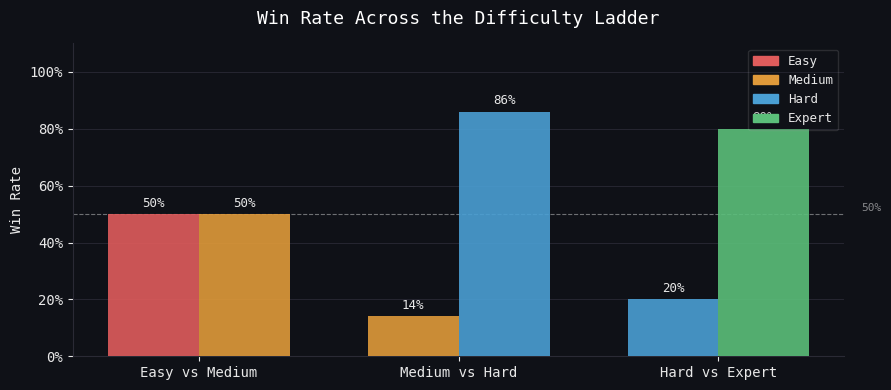

Saved: viz1_winrate_ladder.png


In [13]:
if not _check_results(ALL_KEYS): raise SystemExit

# ── Layout: 2 rows × 3 cols, one panel per matchup ────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
fig.patch.set_facecolor("white")
fig.suptitle("Head-to-Head Win Rates — All Matchups", fontsize=16,
             fontweight="bold", color="black", y=1.01)

for ax, key in zip(axes.flat, ALL_KEYS):
    r = RESULTS[key]
    label_a, label_b = key
    wr_a, wr_b = r["a_winrate"], r["b_winrate"]
    col_a, col_b = COLORS[label_a], COLORS[label_b]

    bars = ax.bar([0, 1], [wr_a, wr_b], color=[col_a, col_b],
                  width=0.5, zorder=3, alpha=0.88)

    # value labels on bars
    for bar, val in zip(bars, [wr_a, wr_b]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f"{val:.0%}", ha="center", va="bottom",
                fontsize=11, fontweight="bold", color="black")

    ax.axhline(0.5, color="gray", linewidth=1.0, linestyle="--", alpha=0.4, zorder=2)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([label_a, label_b], fontsize=11, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Win Rate", fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.grid(axis="y", zorder=1, alpha=0.4)
    ax.set_title(f"{label_a} vs {label_b}  ({r['n_games']} games)",
                 fontsize=10, color="black", pad=6)
    ax.tick_params(colors="black")

plt.tight_layout()
plt.savefig("viz1_winrate_ladder.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: viz1_winrate_ladder.png")


### Visual 2 — Win Rate vs Disc Margin

Win rate was 50/50 for Easy vs Medium — but the disc margin tells a very different story.

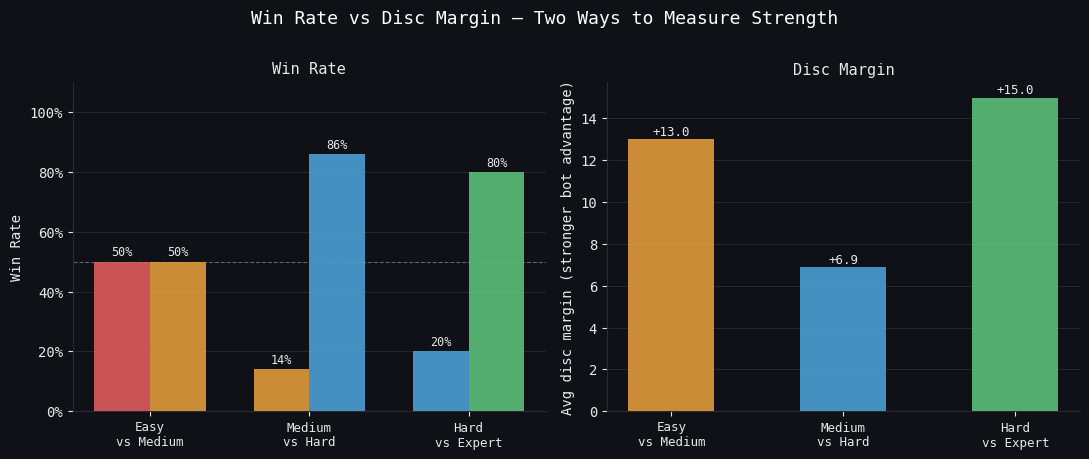

Saved: viz2_winrate_vs_margin.png


In [14]:
if not _check_results(ALL_KEYS): raise SystemExit

# Disc margin: positive = bot_b (the stronger bot) won by more discs on average
labels  = ALL_LABELS
margins = [-RESULTS[k]["avg_margin"] for k in ALL_KEYS]
# colour each bar by the winner (bot_b is always the stronger bot in our ordering)
bar_colors = [COLORS[k[1]] for k in ALL_KEYS]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("white")
fig.suptitle("Win Rate & Disc Margin — All 6 Matchups",
             fontsize=15, fontweight="bold", color="black", y=1.02)

# ── Left: win rate heatmap-style grid ─────────────────────────────────────────
bots = ["Easy", "Medium", "Hard", "Expert"]
n = len(bots)
wr_matrix = [[None]*n for _ in range(n)]
for (a, b), key in zip(ALL_KEYS, ALL_KEYS):
    i, j = bots.index(a), bots.index(b)
    wr_matrix[i][j] = RESULTS[key]["a_winrate"]
    wr_matrix[j][i] = RESULTS[key]["b_winrate"]

data = []
xs, ys, vals, txt_colors = [], [], [], []
for i in range(n):
    for j in range(n):
        v = wr_matrix[i][j]
        if v is None:
            xs.append(j); ys.append(i); vals.append(0.5)
            txt_colors.append("white")
        else:
            xs.append(j); ys.append(i); vals.append(v)
            txt_colors.append("white" if v < 0.65 or v > 0.35 else "black")

cmap_wr = mcolors.LinearSegmentedColormap.from_list("wr", ["#C0392B", "#FFFFFF", "#1E8449"])
norm_wr = mcolors.Normalize(vmin=0, vmax=1)

for x, y, v, tc in zip(xs, ys, vals, txt_colors):
    col = cmap_wr(norm_wr(v)) if wr_matrix[y][x] is not None else "#F5F5F5"
    ax1.add_patch(plt.Rectangle((x-0.5, y-0.5), 1, 1, color=col, zorder=2))
    if wr_matrix[y][x] is not None:
        ax1.text(x, y, f"{v:.0%}", ha="center", va="center",
                 fontsize=12, fontweight="bold", color="black", zorder=3)
    else:
        ax1.text(x, y, "—", ha="center", va="center",
                 fontsize=14, color="#CCCCCC", zorder=3)

ax1.set_xlim(-0.5, n-0.5); ax1.set_ylim(-0.5, n-0.5)
ax1.set_xticks(range(n)); ax1.set_xticklabels(bots, fontsize=11, fontweight="bold")
ax1.set_yticks(range(n)); ax1.set_yticklabels(bots, fontsize=11, fontweight="bold")
for i, b in enumerate(bots): ax1.get_xticklabels()[i].set_color(COLORS[b])
for i, b in enumerate(bots): ax1.get_yticklabels()[i].set_color(COLORS[b])
ax1.set_title("Win Rate (row bot vs column bot)", fontsize=11, pad=10)
ax1.invert_yaxis()
ax1.grid(False)
for spine in ax1.spines.values(): spine.set_visible(False)
ax1.tick_params(length=0)

# ── Right: avg disc margin bar chart ──────────────────────────────────────────
x = np.arange(len(labels))
bars = ax2.bar(x, margins, color=bar_colors, alpha=0.85, zorder=3, width=0.6)
for bar, m in zip(bars, margins):
    ax2.text(bar.get_x() + bar.get_width()/2,
             m + (0.3 if m >= 0 else -0.8),
             f"{m:+.1f}", ha="center", fontsize=9,
             fontweight="bold", color="black")

ax2.axhline(0, color="black", linewidth=0.8, alpha=0.3)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=8.5, rotation=25, ha="right")
ax2.set_ylabel("Avg disc margin\n(positive = right-side bot won by more)", fontsize=9)
ax2.grid(axis="y", zorder=1, alpha=0.35)
ax2.set_title("Average Disc Margin per Matchup", fontsize=11, pad=10)
ax2.tick_params(colors="black")

# legend
patches = [mpatches.Patch(color=COLORS[b], label=b) for b in bots]
ax2.legend(handles=patches, fontsize=9, loc="upper left",
           framealpha=0.9, edgecolor="#CCCCCC")

plt.tight_layout()
plt.savefig("viz2_winrate_vs_margin.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: viz2_winrate_vs_margin.png")


### Visual 3 — Simulations vs Strength

Run this cell to generate the data (takes a few minutes), or use the placeholder values already filled in.

  [██████████████████████████████] 25/25 (100%)  MCTS-10 win rate so far: 36.0%
──────────────────────────────────────────────────
  MCTS-10 vs Heuristic  (25 games)
──────────────────────────────────────────────────
  MCTS-10              wins :    9  (36.0%)
  Heuristic            wins :   15  (60.0%)
  Draws                 :    1  (4.0%)
  Avg disc margin for MCTS- : -11.00
sims=  10  win rate=36.00%
  [██████████████████████████████] 25/25 (100%)  MCTS-25 win rate so far: 40.0%
──────────────────────────────────────────────────
  MCTS-25 vs Heuristic  (25 games)
──────────────────────────────────────────────────
  MCTS-25              wins :   10  (40.0%)
  Heuristic            wins :   14  (56.0%)
  Draws                 :    1  (4.0%)
  Avg disc margin for MCTS- : -5.72
sims=  25  win rate=40.00%
  [██████████████████████████████] 25/25 (100%)  MCTS-50 win rate so far: 52.0%
──────────────────────────────────────────────────
  MCTS-50 vs Heuristic  (25 games)
───────────────────

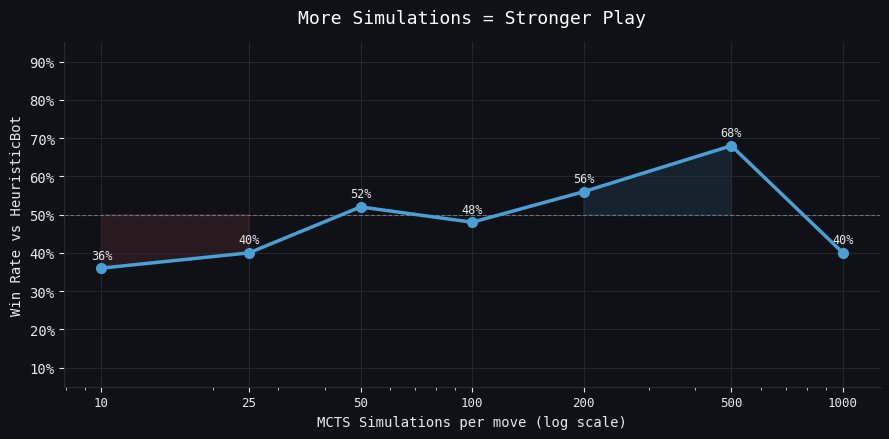

Saved: viz3_simulations_curve.png


In [16]:
# Runs real matchups at different simulation counts and stores into RESULTS
SIM_COUNTS, SIM_WINRATES = [], []
baseline = HeuristicBot()
for sims in [10, 25, 50, 100, 200, 500, 1000]:
    bot = MCTSBot(simulations=sims)
    res = evaluate_matchup(bot, baseline, n_games=25,
                           label_a=f"MCTS-{sims}", label_b="Heuristic",
                           progress_every=1, track_moves=False)
    SIM_COUNTS.append(sims)
    SIM_WINRATES.append(res["a_winrate"])
    print(f"sims={sims:4d}  win rate={res['a_winrate']:.2%}")

fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor("white")

ax.plot(SIM_COUNTS, SIM_WINRATES, color=COLORS["Hard"],
        linewidth=2.5, marker="o", markersize=7, zorder=4)
ax.axhline(0.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.35, zorder=2)
ax.fill_between(SIM_COUNTS, 0.5, SIM_WINRATES,
                where=[w >= 0.5 for w in SIM_WINRATES],
                color=COLORS["Hard"], alpha=0.12, zorder=1)
ax.fill_between(SIM_COUNTS, SIM_WINRATES, 0.5,
                where=[w < 0.5 for w in SIM_WINRATES],
                color=COLORS["Easy"], alpha=0.12, zorder=1)

for s, w in zip(SIM_COUNTS, SIM_WINRATES):
    ax.text(s, w + 0.025, f"{w:.0%}", ha="center", fontsize=8.5, color="black")

ax.set_xscale("log")
ax.set_xlabel("MCTS Simulations per move (log scale)", fontsize=10)
ax.set_ylabel("Win Rate vs HeuristicBot", fontsize=10)
ax.set_ylim(0.05, 0.95)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xticks(SIM_COUNTS); ax.set_xticklabels([str(s) for s in SIM_COUNTS], fontsize=9)
ax.grid(axis="both", zorder=1)
ax.set_title("More Simulations = Stronger Play", fontsize=13, pad=14, color="black")

plt.tight_layout()
plt.savefig("viz3_simulations_curve.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: viz3_simulations_curve.png")


### Visual 4 — Position Weight Heatmap

No simulation needed — this is just the weight table the heuristic bot uses to evaluate board positions.

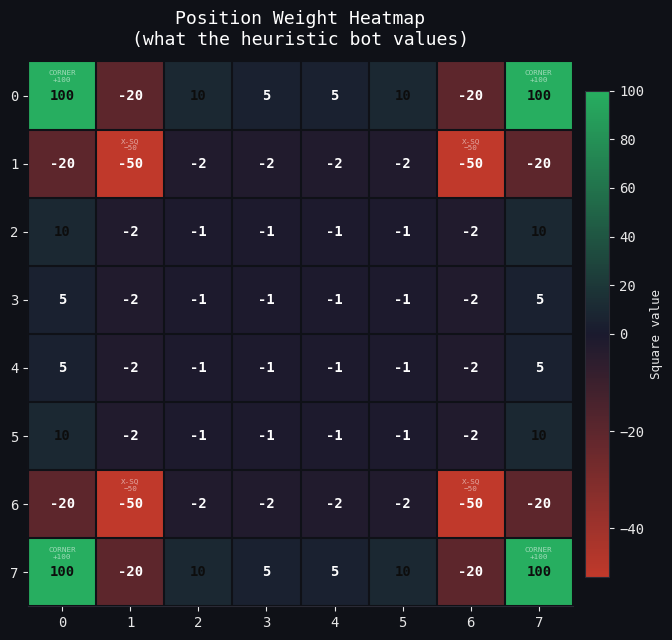

Saved: viz4_position_heatmap.png


In [20]:
POSITION_WEIGHTS_VIZ = np.array([
    [100, -20,  10,   5,   5,  10, -20, 100],
    [-20, -50,  -2,  -2,  -2,  -2, -50, -20],
    [ 10,  -2,  -1,  -1,  -1,  -1,  -2,  10],
    [  5,  -2,  -1,  -1,  -1,  -1,  -2,   5],
    [  5,  -2,  -1,  -1,  -1,  -1,  -2,   5],
    [ 10,  -2,  -1,  -1,  -1,  -1,  -2,  10],
    [-20, -50,  -2,  -2,  -2,  -2, -50, -20],
    [100, -20,  10,   5,   5,  10, -20, 100],
], dtype=float)

fig, ax = plt.subplots(figsize=(7, 6.5))
fig.patch.set_facecolor("white")

cmap = mcolors.LinearSegmentedColormap.from_list(
    "othello", ["#c0392b", "#1a1a2e", "#27ae60"], N=256
)
norm = mcolors.TwoSlopeNorm(vmin=-50, vcenter=0, vmax=100)
im = ax.imshow(POSITION_WEIGHTS_VIZ, cmap=cmap, norm=norm, zorder=2)

# grid lines
for i in range(9):
    ax.axhline(i - 0.5, color="white", linewidth=1.5, zorder=3)
    ax.axvline(i - 0.5, color="white", linewidth=1.5, zorder=3)

# value annotations
for r in range(8):
    for c in range(8):
        v = int(POSITION_WEIGHTS_VIZ[r, c])
        brightness = norm(v)
        txt_color = "white" if brightness < 0.55 else "#0d0d0d"
        ax.text(c, r, str(v), ha="center", va="center",
                fontsize=10, fontweight="bold", color=txt_color, zorder=4)

# corner / zone labels
zone_labels = {
    (0, 0): "CORNER\n+100", (0, 7): "CORNER\n+100",
    (7, 0): "CORNER\n+100", (7, 7): "CORNER\n+100",
    (1, 1): "X-SQ\n−50",    (1, 6): "X-SQ\n−50",
    (6, 1): "X-SQ\n−50",    (6, 6): "X-SQ\n−50",
}
for (r, c), lbl in zone_labels.items():
    ax.text(c, r - 0.28, lbl, ha="center", va="center",
            fontsize=5.5, color="white", alpha=0.55, zorder=5)

cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label("Square value", color="black", fontsize=9)
cbar.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="black")

ax.set_xticks(range(8)); ax.set_xticklabels(list("01234567"))
ax.set_yticks(range(8)); ax.set_yticklabels(list("01234567"))
ax.set_title("Position Weight Heatmap\n(what the heuristic bot values)",
             fontsize=13, color="black", pad=12)

plt.tight_layout()
plt.savefig("viz4_position_heatmap.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: viz4_position_heatmap.png")

### Visual 5 — Move Frequency Heatmaps

Move frequency data is collected **during the simulation matchups** — no extra
games needed. Each heatmap shows where that bot placed its pieces across all games.


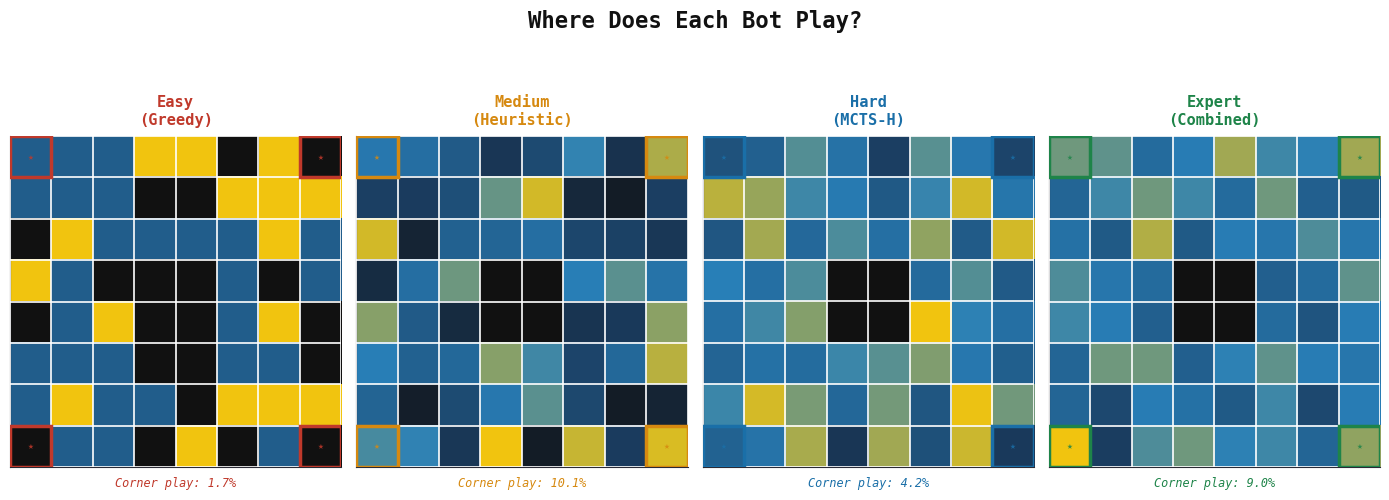

Saved: viz5_move_frequency.png


In [30]:
if not _check_results(ALL_KEYS): raise SystemExit

# Pool every appearance of each bot across all matchups for maximum sample size
def pool_freq(*arrays):
    """Average a list of 8x8 frequency arrays, each already normalised to 100%."""
    combined = sum(arrays)
    total = combined.sum() or 1
    return combined / total * 100

freq_easy = pool_freq(
    RESULTS[("Easy", "Medium")]["freq_a"],
    RESULTS[("Easy", "Hard")]["freq_a"],
    RESULTS[("Easy", "Expert")]["freq_a"],
)
freq_medium = pool_freq(
    RESULTS[("Easy",   "Medium")]["freq_b"],
    RESULTS[("Medium", "Hard")]["freq_a"],
    RESULTS[("Medium", "Expert")]["freq_a"],
)
freq_hard = pool_freq(
    RESULTS[("Medium", "Hard")]["freq_b"],
    RESULTS[("Easy",   "Hard")]["freq_b"],
    RESULTS[("Hard",   "Expert")]["freq_a"],
)
freq_expert = pool_freq(
    RESULTS[("Hard",   "Expert")]["freq_b"],
    RESULTS[("Easy",   "Expert")]["freq_b"],
    RESULTS[("Medium", "Expert")]["freq_b"],
)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
fig.patch.set_facecolor("white")

bot_labels = ["Easy\n(Greedy)", "Medium\n(Heuristic)", "Hard\n(MCTS-H)", "Expert\n(Combined)"]
freqs      = [freq_easy, freq_medium, freq_hard, freq_expert]
bot_colors = [COLORS["Easy"], COLORS["Medium"], COLORS["Hard"], COLORS["Expert"]]

cmap_freq = mcolors.LinearSegmentedColormap.from_list(
    "freq", ["#111111", "#1a3a5c", "#2980b9", "#f1c40f"])

corner_positions = [(0,0),(0,7),(7,0),(7,7)]

for ax, freq, label, col in zip(axes, freqs, bot_labels, bot_colors):
    ax.imshow(freq, cmap=cmap_freq, vmin=0, vmax=freq.max(), zorder=2)

    for i in range(9):
        ax.axhline(i - 0.5, color="white", linewidth=1.2, zorder=3)
        ax.axvline(i - 0.5, color="white", linewidth=1.2, zorder=3)

    for (r, c) in corner_positions:
        ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1,
                     fill=False, edgecolor=col, linewidth=2.5, zorder=4))
        ax.text(c, r, "★", ha="center", va="center",
                fontsize=7, color=col, zorder=5, alpha=0.85)

    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(label, fontsize=11, color=col, pad=8,
                 fontweight="bold", fontfamily="monospace")

    corner_pct = sum(freq[r,c] for r,c in corner_positions)
    ax.text(0.5, -0.06, f"Corner play: {corner_pct:.1f}%",
            transform=ax.transAxes, ha="center", fontsize=8.5,
            color=col, style="italic")

fig.suptitle("Where Does Each Bot Play?",
             fontsize=16, fontweight="bold", color="black", y=1.02)
fig.text(0.5, 0.97,
         "Brighter = more frequent  ·  ★ marks corners  ·  stronger bots concentrate on corners and edges",
         ha="center", fontsize=9, color="#555555")

plt.tight_layout(rect=[0, 0.0, 1, 0.95])
plt.savefig("viz5_move_frequency.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: viz5_move_frequency.png")


### Visual 6 — Rollout Strategy Comparison

Random vs heuristic rollouts at the same simulation budgets. Shows that *how* you simulate matters.

  [██████████████████████████████] 25/25 (100%)  MCTS-rand-25 win rate so far: 36.0%
──────────────────────────────────────────────────
  MCTS-rand-25 vs Heuristic  (25 games)
──────────────────────────────────────────────────
  MCTS-rand-25         wins :    9  (36.0%)
  Heuristic            wins :   16  (64.0%)
  Draws                 :    0  (0.0%)
  Avg disc margin for MCTS- : -12.52
  [██████████████████████████████] 25/25 (100%)  MCTS-heur-25 win rate so far: 56.0%
──────────────────────────────────────────────────
  MCTS-heur-25 vs Heuristic  (25 games)
──────────────────────────────────────────────────
  MCTS-heur-25         wins :   14  (56.0%)
  Heuristic            wins :   10  (40.0%)
  Draws                 :    1  (4.0%)
  Avg disc margin for MCTS- : -2.80
  [██████████████████████████████] 25/25 (100%)  MCTS-rand-50 win rate so far: 44.0%
──────────────────────────────────────────────────
  MCTS-rand-50 vs Heuristic  (25 games)
───────────────────────────────────────────

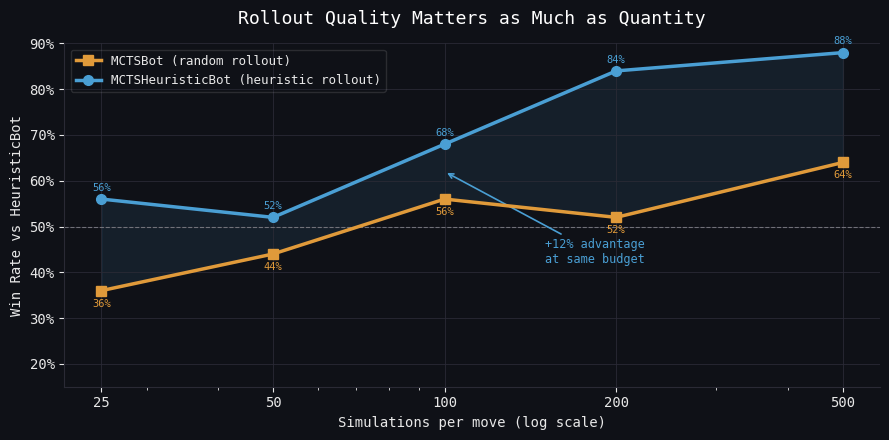

Saved: viz6_rollout_comparison.png


In [21]:
# ── Visual 6: Rollout Strategy Comparison — DATA COLLECTION ───────────────────
# Runs MCTSBot (random rollout) and MCTSHeuristicBot (heuristic rollout) at
# multiple simulation budgets, each against a fixed HeuristicBot baseline.
SIM_BUDGETS, WR_RANDOM, WR_HEURISTIC = [], [], []
baseline = HeuristicBot()
for sims in [25, 50, 100, 200, 500]:
    r_rand = evaluate_matchup(MCTSBot(simulations=sims), baseline, n_games=25,
                              label_a=f"MCTS-rand-{sims}", label_b="Heuristic",
                              progress_every=5, track_moves=False)
    r_heur = evaluate_matchup(MCTSHeuristicBot(simulations=sims), baseline, n_games=25,
                              label_a=f"MCTS-heur-{sims}", label_b="Heuristic",
                              progress_every=5, track_moves=False)
    SIM_BUDGETS.append(sims)
    WR_RANDOM.append(r_rand["a_winrate"])
    WR_HEURISTIC.append(r_heur["a_winrate"])
    print(f"sims={sims:4d}  random={r_rand['a_winrate']:.2%}  heuristic={r_heur['a_winrate']:.2%}")

print("\nData collection complete. Run the next cell to plot.")


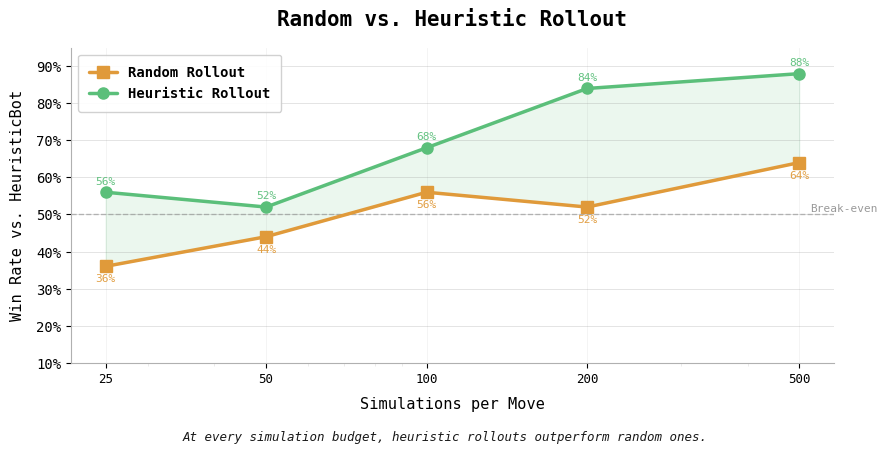

Saved: viz6_rollout_comparison_white.png


In [28]:
# ── Visual 6: Rollout Strategy Comparison — PLOT ──────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.plot(SIM_BUDGETS, WR_RANDOM, color=COLORS["Medium"], linewidth=2.5,
        marker="s", markersize=8, label="Random Rollout", zorder=4,
        solid_capstyle="round")
ax.plot(SIM_BUDGETS, WR_HEURISTIC, color=COLORS["Hard"], linewidth=2.5,
        marker="o", markersize=8, label="Heuristic Rollout", zorder=4,
        solid_capstyle="round")

ax.axhline(0.5, color="gray", linewidth=1.0, linestyle="--", alpha=0.5, zorder=2)
ax.text(SIM_BUDGETS[-1] * 1.05, 0.502, "Break-even",
        fontsize=8, color="gray", alpha=0.8, va="bottom")

ax.fill_between(SIM_BUDGETS, WR_RANDOM, WR_HEURISTIC,
                color=COLORS["Hard"], alpha=0.10, zorder=1)

for s, wr, wh in zip(SIM_BUDGETS, WR_RANDOM, WR_HEURISTIC):
    ax.text(s, wr - 0.042, f"{wr:.0%}", ha="center", fontsize=8,
            color=COLORS["Medium"], alpha=0.95)
    ax.text(s, wh + 0.022, f"{wh:.0%}", ha="center", fontsize=8,
            color=COLORS["Hard"], alpha=0.95)

ax.set_xscale("log")
ax.set_xlabel("Simulations per Move", fontsize=11, labelpad=8, color="black")
ax.set_ylabel("Win Rate vs. HeuristicBot", fontsize=11, labelpad=8, color="black")
ax.set_ylim(0.10, 0.95)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xticks(SIM_BUDGETS)
ax.set_xticklabels([str(s) for s in SIM_BUDGETS], fontsize=9, color="black")
ax.tick_params(colors="black")
ax.yaxis.set_tick_params(labelcolor="black")
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_color("#CCCCCC")
ax.grid(axis="y", zorder=1, alpha=0.3, color="gray")
ax.grid(axis="x", zorder=1, alpha=0.1, color="gray")

legend = ax.legend(frameon=True, fontsize=10, loc="upper left",
                   borderpad=0.8, handlelength=2)
for text in legend.get_texts():
    text.set_color("black")
legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("#CCCCCC")

ax.set_title("Random vs. Heuristic Rollout", fontsize=15, pad=16,
             color="black", fontweight="bold")
fig.text(0.5, 0.01,
         "At every simulation budget, heuristic rollouts outperform random ones.",
         ha="center", fontsize=9, color="black", alpha=0.5, style="italic")

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("viz6_rollout_comparison.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: viz6_rollout_comparison.png")
